# Black Friday

> What is black friday?

Black Friday refers to the Friday following Thanksgiving in the United States, which marks the unofficial beginning of the holiday shopping season. It is globally known for massive promotional sales, deep retail discounts, and enormous crowds of consumers.

#### About Datasets :
This file contains 100,000 retail transaction records capturing customer purchasing behavior during Black Friday and promotional sales events.

Each row represents a single purchase and includes information about customer demographics, product category, pricing, discounts, quantity, and final transaction value.

The dataset combines transactional, pricing, and behavioral attributes, making it suitable for analyzing how discounts, customer segments, and product categories influence purchasing decisions during high-demand retail periods.

It is structured to support both exploratory data analysis and machine learning workflows, enabling users to study sales patterns, customer behavior, and revenue trends.

Data source : https://www.kaggle.com/datasets/noopurbhatt/retail-black-friday-sales-dataset/data



## Main Question

How do discounts, customer segments, product categories, and purchase timing influence sales performance during the Black Friday promotional period?

In [2]:
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noopurbhatt/retail-black-friday-sales-dataset")

print("Path to dataset files:", path)
available_files = sorted(os.listdir(path))
available_files

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\noopurbhatt\retail-black-friday-sales-dataset\versions\1


['retail_black_friday_sales_100k.csv']

In [4]:
df = pd.read_csv(os.path.join(path, 'retail_black_friday_sales_100k.csv'))

## Chapter 1 : Data Overview

In [5]:
df.rename(columns={'purchase_date': 'date'}, inplace=True)
df['date'] = (pd.to_datetime(df['date'])
              + pd.to_timedelta(df['purchase_hour'], unit='h')
              )
cols = ['date'] + [col for col in df.columns if col != 'date']
df = df[cols]


df = df.sort_values('date')

df.head()

,date,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_hour,is_weekend,is_black_friday
75143,2025-11-24,T0075144,C006682,46-55,Female,Houston,Returning,P6651,Footwear,80.83,35,52.54,1,52.54,Mobile Wallet,0,0,0
40042,2025-11-24,T0040043,C005592,18-25,Male,Miami,Returning,P2334,Toys,31.36,5,29.79,1,29.79,Debit Card,0,0,0
54040,2025-11-24,T0054041,C015267,26-35,Female,Seattle,Loyal,P9781,Accessories,104.88,30,73.42,1,73.42,Credit Card,0,0,0
75827,2025-11-24,T0075828,C016258,36-45,Female,Miami,Returning,P2355,Footwear,325.79,10,293.21,1,293.21,Mobile Wallet,0,0,0
54123,2025-11-24,T0054124,C006349,18-25,Female,Atlanta,New,P9520,Accessories,436.15,5,414.34,1,414.34,Cash,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 75143 to 36194
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              100000 non-null  datetime64[us]
 1   transaction_id    100000 non-null  str           
 2   customer_id       100000 non-null  str           
 3   age_group         100000 non-null  str           
 4   gender            100000 non-null  str           
 5   city              100000 non-null  str           
 6   customer_segment  100000 non-null  str           
 7   product_id        100000 non-null  str           
 8   product_category  100000 non-null  str           
 9   original_price    100000 non-null  float64       
 10  discount_pct      100000 non-null  int64         
 11  final_price       100000 non-null  float64       
 12  quantity          100000 non-null  int64         
 13  purchase_amount   100000 non-null  float64       
 14  payment_method   

In [12]:
start_date = df['date'].min().date()
end_date = df['date'].max().date()
total_days = total_days = df['date'].dt.date.nunique()

print("\t",15*"="," DATA OVERVIEW ", 15*"=")

overview = pd.DataFrame({
    "Metric": [
        "Date Range",
        "Total Days",
        "Total Transactions",
        "Unique Customers",
        "Unique Products",
        "Total Revenue",
        "Average Transaction",
        "Mean Original Price",
        "Mean Final Price",
        "Mean Discount (%)",
        "Max Discount (%)",
        "Mean Quantity",
        "Total Items Sold",
        "Highest Purchase",
        "Lowest Purchase"
    ],
    "Value": [
        f"{start_date} -> {end_date}",
        total_days,
        len(df),
        df['customer_id'].nunique(),
        df['product_id'].nunique(),
        round(df['purchase_amount'].sum(), 2),
        round(df['purchase_amount'].mean(), 2),
        round(df['original_price'].mean(), 2),
        round(df['final_price'].mean(), 2),
        round(df['discount_pct'].mean(), 2),
        df['discount_pct'].max(),
        round(df['quantity'].mean(), 2),
        df['quantity'].sum(),
        round(df['purchase_amount'].max(), 2),
        round(df['purchase_amount'].min(), 2)
    ]
})

overview


	 ===============  DATA OVERVIEW  ===============


,Metric,Value
0,Date Range,2025-11-24 -> 2025-12-01
1,Total Days,8
2,Total Transactions,100000
3,Unique Customers,32997
4,Unique Products,9000
5,Total Revenue,35125630.67
6,Average Transaction,351.26
7,Mean Original Price,330.28
8,Mean Final Price,242.22
9,Mean Discount (%),26.63


## Chapter 2 : Data Quality Check

In [8]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index(name='missing_count')
      .rename(columns={'index': 'column'})
)

missing_summary['missing_pct'] = (
    missing_summary['missing_count'] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    'missing_pct',
    ascending=False
)

missing_summary

,column,missing_count,missing_pct
0,date,0,0.0
1,transaction_id,0,0.0
2,customer_id,0,0.0
3,age_group,0,0.0
4,gender,0,0.0
5,city,0,0.0
6,customer_segment,0,0.0
7,product_id,0,0.0
8,product_category,0,0.0
9,original_price,0,0.0


In [9]:
numerical_cols = [
    'original_price',
    'discount_pct',
    'final_price',
    'quantity',
    'purchase_amount',
    'purchase_hour'
]

outlier_summary = []

for col in numerical_cols:

    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_summary.append({
        'column': col,
        'count': len(series),
        'mean': round(series.mean(), 2),
        'median': round(series.median(), 2),
        'min': round(series.min(), 2),
        'max': round(series.max(), 2),
        'iqr_lower_bound': round(lower_bound, 2),
        'iqr_upper_bound': round(upper_bound, 2),
        'outlier_count': outlier_count,
        'outlier_pct': round(outlier_count / len(series) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    'outlier_pct',
    ascending=False
)

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
0,original_price,100000,330.28,180.22,5.00,2499.89,-280.27,702.10,11819,11.82
2,final_price,100000,242.22,129.49,2.07,2374.90,-214.01,524.53,11476,11.48
4,purchase_amount,100000,351.26,161.15,2.22,11441.80,-348.71,783.18,10897,10.90
3,quantity,100000,1.45,1.00,1.00,5.00,-0.50,3.50,3979,3.98
1,discount_pct,100000,26.63,25.00,5.00,60.00,-2.50,57.50,1997,2.00
5,purchase_hour,100000,11.48,11.00,0.00,23.00,-13.00,35.00,0,0.00


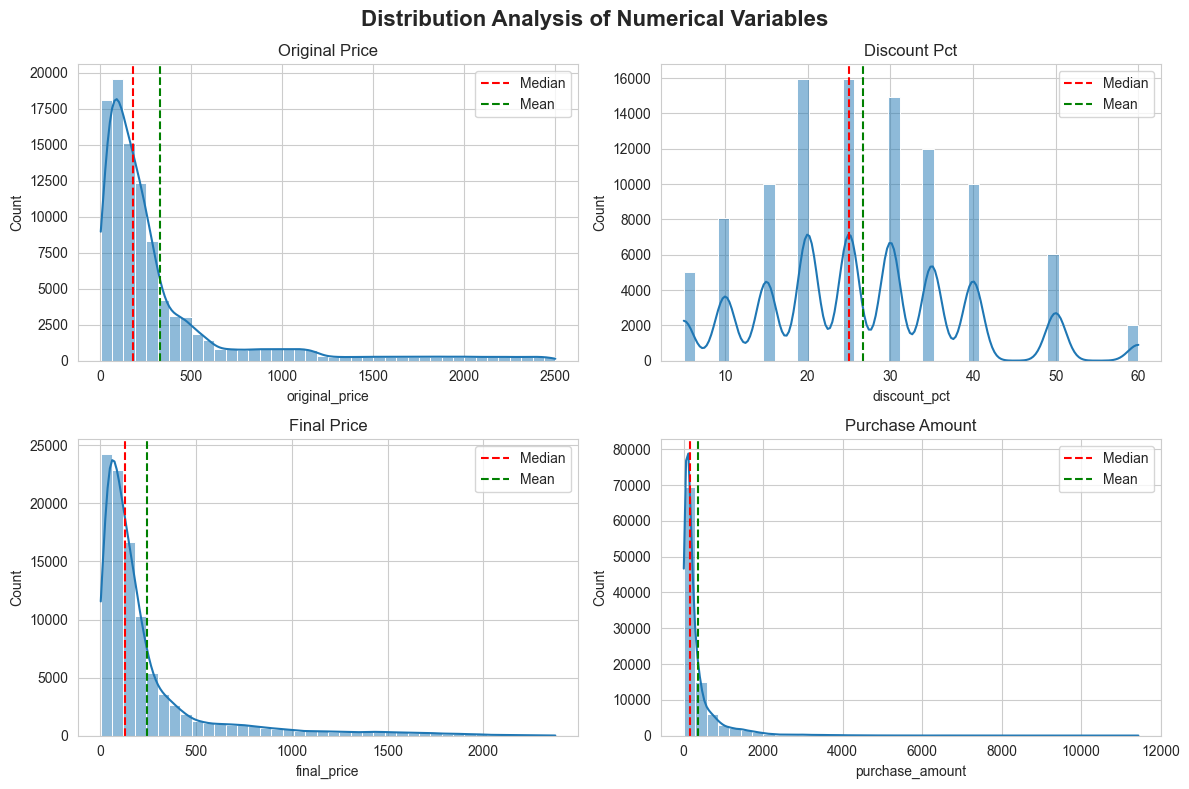

In [14]:
target_columns = [
    'original_price',
    'discount_pct',
    'final_price',
    'purchase_amount'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, target_columns):

    sns.histplot(
        df[col],
        bins=40,
        kde=True,
        ax=ax
    )

    ax.axvline(
        df[col].median(),
        color='red',
        linestyle='--',
        label='Median'
    )

    ax.axvline(
        df[col].mean(),
        color='green',
        linestyle='--',
        label='Mean'
    )

    ax.set_title(col.replace('_', ' ').title())
    ax.legend()
    
plt.suptitle(
    'Distribution Analysis of Numerical Variables',
    fontsize=16,
    weight='bold'
)

plt.tight_layout()
plt.show()

## Chapter 3 : Exploration Data Analysis

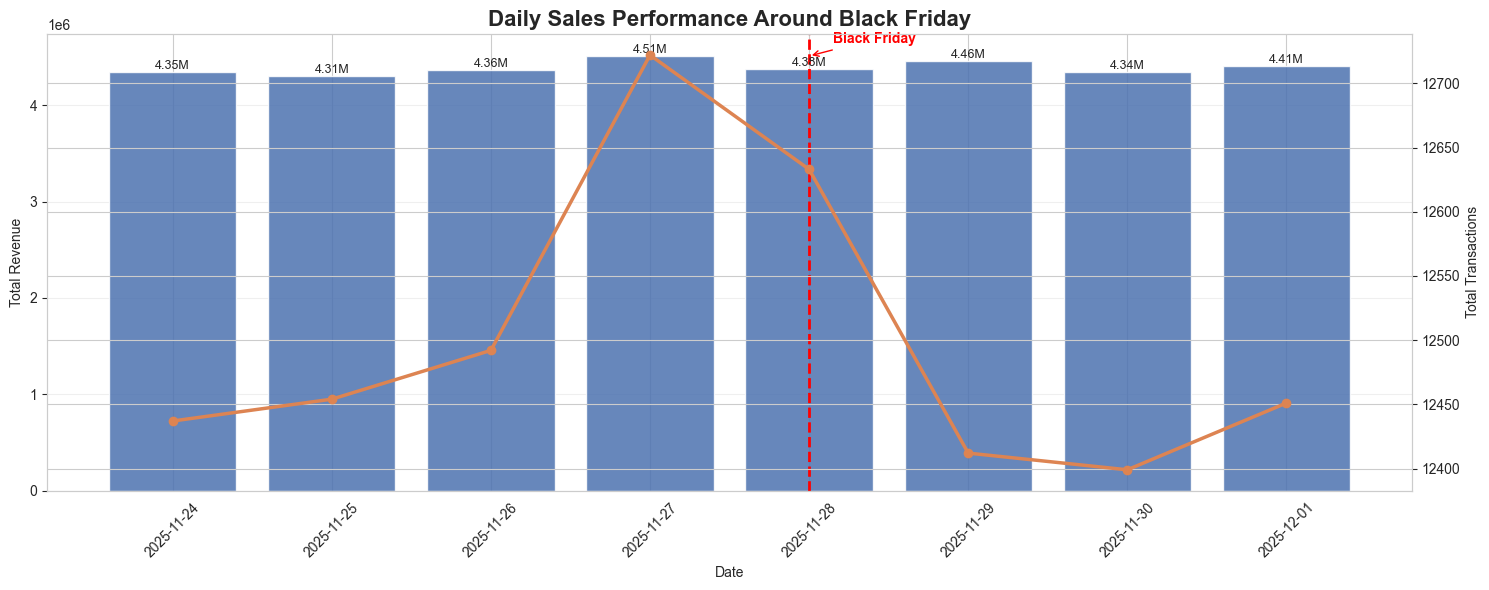

In [30]:
df_daily = (
    df.groupby(pd.Grouper(key='date', freq='D'))
      .agg(
          transactions=('transaction_id', 'count'),
          revenue=('purchase_amount', 'sum'),
          avg_purchase=('purchase_amount', 'mean')
      )
      .reset_index()
)

black_friday_date = df.loc[
    df['is_black_friday'] == 1,
    'date'
].dt.normalize().iloc[0]

x_pos = np.arange(len(df_daily))

black_friday_idx = df_daily.index[
    df_daily['date'] == black_friday_date
][0]

fig, ax1 = plt.subplots(figsize=(15, 6))

bars = ax1.bar(
    x_pos,
    df_daily['revenue'],
    color='#4C72B0',
    alpha=0.85,
    label='Revenue'
)

ax1.set_title(
    'Daily Sales Performance Around Black Friday',
    fontsize=16,
    weight='bold'
)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Revenue')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(
    df_daily['date'].dt.strftime('%Y-%m-%d'),
    rotation=45
)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height/1_000_000:.2f}M',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2 = ax1.twinx()

ax2.plot(
    x_pos,
    df_daily['transactions'],
    marker='o',
    color='#DD8452',
    linewidth=2.5,
    label='Transactions'
)

ax2.set_ylabel('Total Transactions')

ax1.axvline(
    x=black_friday_idx,
    color='red',
    linestyle='--',
    linewidth=2
)

ax1.annotate(
    'Black Friday',
    xy=(black_friday_idx, df_daily['revenue'].max()),
    xytext=(black_friday_idx + 0.15, df_daily['revenue'].max() * 1.03),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red',
    weight='bold'
)

ax1.grid(True, axis='y', alpha=0.3)

os.makedirs('plots', exist_ok=True)
filepath = os.path.join('plots', "Daily Sales Performance Around Black Friday.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')

plt.tight_layout()
plt.show()

In [16]:
print(df_daily['date'].dtype)

object
